<a href="https://colab.research.google.com/github/marciomalrj/MVPML/blob/main/MVP_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Márcio Miranda da Silva  
**Matrícula:** 4052025002387  
**Data:** 04/07/2026  
**Dataset:**  [Vendas com Faturamento](https://github.com/marciomalrj/MVPML/blob/main/VendasFaturamento.CSV)  
**Tipo de problema:**  Classificação Supervisionada  


# 1. Definição do problema

## 1.1 Descrição do problema

O setor de vendas gera diariamente uma grande quantidade de dados relacionados a produtos, clientes, categorias, preços e regiões de comercialização. A análise desses dados permite identificar padrões de comportamento e criar modelos capazes de auxiliar na tomada de decisão.
Neste trabalho será desenvolvido um MVP de Machine Learning com o objetivo de prever o potencial de vendas de produtos a partir de características disponíveis no histórico de vendas.



## 1.2 Objetivo do MVP

O objetivo deste projeto é construir um modelo de classificação capaz de prever se uma venda pertence a uma das seguintes categorias:  
1. Venda Baixa
2. Venda Média
3. Venda Alta   

A classificação será realizada com base em informações como produto, categoria, marca, país, continente, preço unitário e período da venda.


## 1.3 Tipo de problema

Este projeto caracteriza-se como um problema de Classificação Supervisionada, pois existe uma variável-alvo previamente definida e rotulada, utilizada para treinar o modelo.



## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses:**
1. As características dos produtos e do contexto da venda (produto, categoria, marca, preço, custo, país, continente e período da venda) possuem informações suficientes para prever a classe de venda (Venda Baixa, Venda Média ou Venda Alta).

2. A combinação de múltiplas variáveis apresenta maior capacidade preditiva do que a análise isolada de uma única variável.

3. Modelos baseados em árvores, como Decision Tree e Random Forest, serão capazes de capturar relações não lineares presentes nos dados e apresentar desempenho superior aos modelos lineares e à baseline no problema de classificação.


### Critérios de sucesso

**Métrica principal**

Foi adotado o **F1-score ponderado (F1 Weighted)** como principal métrica de avaliação. Essa escolha foi motivada pelo desbalanceamento da variável alvo, já que a classe Venda Baixa representa a maior parte dos registros. O F1-score ponderado permite avaliar simultaneamente precisão e recall das diferentes classes, fornecendo uma visão mais equilibrada do desempenho do modelo.

**Resultado mínimo esperado**

* Superar o desempenho da baseline em F1-score ponderado.
* Demonstrar capacidade de identificar as classes Venda Baixa), Venda Média e Venda Alta.
* Obter desempenho superior ao modelo linear de referência (Logistic Regression).

**Restrições práticas**

* Utilizar apenas informações disponíveis no momento da venda, evitando vazamento de dados.
* Manter o treinamento compatível com os recursos computacionais disponíveis no Google Colab.
* Utilizar uma solução reproduzível por meio de divisão controlada dos dados e uso de semente aleatória fixa (SEED = 42).
* Priorizar modelos que apresentem equilíbrio entre desempenho, simplicidade de implementação e capacidade de generalização.



# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [1]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Funções auxiliares



In [2]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T

## Carregar os dados
def carregar_dados(url):
    df = pd.read_csv(url, sep=";", encoding="ISO-8859-1")
    return df



# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

A base de dados retrata vendas feitas de variados produtos em diversos países de distintos continentes.

- **Nome do Dataset:** VendasFaturamento.CSV
- **Link da fonte:** https://github.com/marciomalrj/MVPML/blob/main/VendasFaturamento.CSV
- **Por que esse dataset foi escolhido:** Com o crescimento das vendas descentralizadas crescendo no mundo, ele demonstra uma pequena fatia desse mercado.
- **Quais restrições ou condições foram consideradas:** Não se aplica.
- **Há questões de ética, privacidade, confidencialidade ou licença:** Não se aplica.


## 3.2 Carga dos dados

In [3]:
# ==============================
# CARREGAMENTO DOS DADOS
# ==============================

fonte = "https://raw.githubusercontent.com/marciomalrj/MVPML/main/VendasFaturamento.CSV"
df = carregar_dados(fonte)

print("Formato do dataset:", df.shape)
display(df.head())


Formato do dataset: (203888, 11)


,DataVenda,Produto,Categoria,PrecoUnitario,CustoUnitario,Marca,Qtd_Vendida,Faturamento,NomeCliente,Pais,Continente
0,01/06/2017,Sistema de Som 7.1 Channel X711 Prata,Sistema de Som,1109,"367,43",Litware,1.0,1109,Vicente Pinheiro,França,Europa
1,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,1.0,"215,62",Marlon Lopez,Estados Unidos,América do Norte
2,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,1.0,"215,62",Martin Gonzalez,Chile,América do Sul
3,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,1.0,"215,62",Victor Ruiz,Alemanha,Europa
4,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,5.0,"1078,1",Alex Nelson,Estados Unidos,América do Norte


In [4]:
# ==============================
# EXIBINDO ÚLTIMAS LINHAS
# ==============================

df.tail()

,DataVenda,Produto,Categoria,PrecoUnitario,CustoUnitario,Marca,Qtd_Vendida,Faturamento,NomeCliente,Pais,Continente
203883,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203884,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203885,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203886,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203887,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ==============================
# REMOVENDO LINHAS EM QUE TODOS DADOS ESTEJAM VAZIOS
# ==============================

df = pd.DataFrame(df)
df.dropna(how="all", subset=df.columns[1:], inplace=True)
df.tail()

,DataVenda,Produto,Categoria,PrecoUnitario,CustoUnitario,Marca,Qtd_Vendida,Faturamento,NomeCliente,Pais,Continente
203877,31/08/2019,Wireless Azultooth Stereo Headphones M402 Verde,Headphone Bluetooth,"99,99","45,98",Northwind Traders,1.0,"99,99",Jennifer Hughes,Reino Unido,Europa
203878,31/08/2019,Wireless Azultooth Stereo Headphones M402 Verde,Headphone Bluetooth,"99,99","45,98",Northwind Traders,5.0,"499,95",Mary Adams,Chile,América do Sul
203879,31/08/2019,Wireless Azultooth Stereo Headphones M402 Verde,Headphone Bluetooth,"99,99","45,98",Northwind Traders,3.0,"299,97",Morgan Rivera,Estados Unidos,América do Norte
203880,31/08/2019,Wireless Azultooth Stereo Headphones M402 Verde,Headphone Bluetooth,"99,99","45,98",Northwind Traders,1.0,"99,99",Adam Kumar,Estados Unidos,América do Norte
203881,31/08/2019,Wireless Azultooth Stereo Headphones M402 Verm...,Headphone Bluetooth,"99,99","45,98",Northwind Traders,3.0,"299,97",Fernando Rodriguez,Estados Unidos,América do Norte


In [6]:
# CRIANDO A COLUNA CLASSE VENDA QUE SERÁ NOSSA TARGET

qtd1 = df["Qtd_Vendida"].quantile(0.33)
qtd2 = df["Qtd_Vendida"].quantile(0.66)

def classificar_venda(qtd):
    if qtd <= qtd1:
        return "Venda Baixa"
    elif qtd <= qtd2:
        return "Venda Média"
    else:
        return "Venda Alta"

df["ClasseVenda"] = df["Qtd_Vendida"].apply(classificar_venda)
display(df.head(10))

,DataVenda,Produto,Categoria,PrecoUnitario,CustoUnitario,Marca,Qtd_Vendida,Faturamento,NomeCliente,Pais,Continente,ClasseVenda
0,01/06/2017,Sistema de Som 7.1 Channel X711 Prata,Sistema de Som,1109,"367,43",Litware,1.0,1109,Vicente Pinheiro,França,Europa,Venda Baixa
1,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,1.0,"215,62",Marlon Lopez,Estados Unidos,América do Norte,Venda Baixa
2,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,1.0,"215,62",Martin Gonzalez,Chile,América do Sul,Venda Baixa
3,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,1.0,"215,62",Victor Ruiz,Alemanha,Europa,Venda Baixa
4,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,5.0,"1078,1",Alex Nelson,Estados Unidos,América do Norte,Venda Alta
5,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,1.0,"215,62",Daisy Alvarez,Estados Unidos,América do Norte,Venda Baixa
6,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,2.0,"431,24",Margaret Wang,Estados Unidos,América do Norte,Venda Média
7,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,4.0,"862,48",Edwin Kumar,França,Europa,Venda Alta
8,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,1.0,"215,62",Nathaniel Sanchez,Estados Unidos,América do Norte,Venda Baixa
9,01/06/2017,180 CFM Ventilador de Coluna X450 Preto,Ventiladores,"215,62","71,44",Litware,1.0,"215,62",Kelly Butler,Estados Unidos,América do Norte,Venda Baixa


In [7]:
# AJUSTANDO AS COLUNAS MONETÁRIAS PARA NÃO DAR ERRO DE ANÁLISE
colunas_monetarias = ["PrecoUnitario", "CustoUnitario", "Faturamento"]

for coluna in colunas_monetarias:
    df[coluna] = (
        df[coluna]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

df[colunas_monetarias + ["Qtd_Vendida"]].dtypes

,0
PrecoUnitario,float64
CustoUnitario,float64
Faturamento,float64
Qtd_Vendida,float64


In [8]:
# CONVERTER DATAVENDA PARA DATETIME
df["DataVenda"] = pd.to_datetime(
    df["DataVenda"],
    format="%d/%m/%Y"
)

print(df["DataVenda"].dtype)

datetime64[ns]


In [9]:
# REMOVER ESPAÇOS EXTRAS EM COLUNAS CATEGÓRICAS
colunas_texto = [
    "Produto",
    "Categoria",
    "Marca",
    "NomeCliente",
    "Pais",
    "Continente"
]

for coluna in colunas_texto:
    df[coluna] = df[coluna].astype(str).str.strip()

## 3.3 Visão geral do dataset

Antes de modelar, apresente uma visão geral da base.

**O que incluir:**
- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.


In [10]:
# ==============================
# DEMOSTRANDO O FORMATO DO DATASET
# ==============================

print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (203882, 12)

Tipos de dados:


,tipo
DataVenda,datetime64[ns]
Produto,object
Categoria,object
PrecoUnitario,float64
CustoUnitario,float64
Marca,object
Qtd_Vendida,float64
Faturamento,float64
NomeCliente,object
Pais,object


In [11]:
# ==============================
# VERIFICANDO DADOS AUSENTES
# ==============================

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
DataVenda,0
Produto,0
Categoria,0
PrecoUnitario,0
CustoUnitario,0
Marca,0
Qtd_Vendida,0
Faturamento,0
NomeCliente,0
Pais,0


In [12]:
# ==============================
# VERIFICANDO DADOS AUSENTES
# ==============================

print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 32789


Foram identificados 32.789 registros duplicados. Os registros foram mantidos por não haver evidências de inconsistência nos dados e por poderem representar ocorrências legítimas de vendas com características idênticas.

## 3.4 Dicionário de dados

| Coluna        | Tipo       | Descrição                         | Será usada no modelo? | Observações                                                                   |
| ------------- | ---------- | --------------------------------- | --------------------- | ----------------------------------------------------------------------------- |
| DataVenda     | Data       | Data em que a venda foi realizada | Sim                   | Poderá ser transformada em atributos temporais durante a preparação dos dados |
| Produto       | Categórica | Nome do produto vendido           | Sim                   | Característica do produto                                                     |
| Categoria     | Categórica | Categoria do produto              | Sim                   | Segmentação dos produtos                                                      |
| PrecoUnitario | Numérica   | Preço unitário do produto         | Sim                   | Pode influenciar o comportamento de compra                                    |
| CustoUnitario | Numérica   | Custo unitário do produto         | Sim                   | Característica econômica do produto                                           |
| Marca         | Categórica | Marca do produto                  | Sim                   | Pode influenciar o desempenho de vendas                                       |
| Qtd_Vendida   | Numérica   | Quantidade vendida                | Não                   | Utilizada apenas para gerar a variável-alvo                                   |
| Faturamento   | Numérica   | Valor total da venda              | Não                   | Não será utilizada para evitar vazamento de dados                             |
| NomeCliente   | Texto      | Nome do cliente                   | Não                   | Alta cardinalidade e pouca capacidade de generalização                        |
| Pais          | Categórica | País da venda                     | Sim                   | Informação geográfica                                                         |
| Continente    | Categórica | Continente da venda               | Sim                   | Informação geográfica agregada                                                |
| ClasseVenda   | Alvo       | Classificação da venda            | Alvo                  | Variável alvo criada para o problema de classificação                         |



# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


In [13]:
# AJUSTE ESTAS VARIÁVEIS CONFORME SEU PROBLEMA.
TARGET = "ClasseVenda"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
ClasseVenda,
Venda Baixa,123402
Venda Alta,60592
Venda Média,19888


,percentual
ClasseVenda,
Venda Baixa,60.53
Venda Alta,29.72
Venda Média,9.75


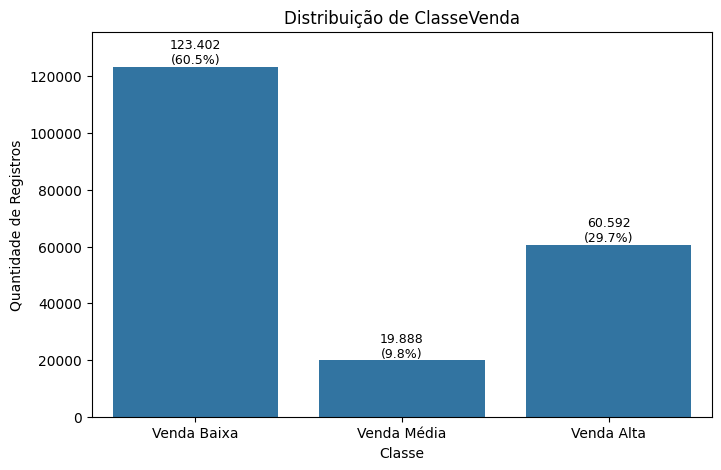

In [14]:
# DISTRIBUIÇÃO DO TARGET

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x=TARGET,
    order=["Venda Baixa","Venda Média","Venda Alta"]
)

# Adicionando os valores sobre as barras
total = len(df)
alturaColuna = 0

for p in ax.patches:
    valor = p.get_height()
    if valor > alturaColuna: # pegar o maior valor para ajustar o gráfico
        alturaColuna = valor
    percentual = valor / total * 100

    ax.annotate(
        f'{valor:,.0f}\n({percentual:.1f}%)'.replace(',', '.'),
        (p.get_x() + p.get_width()/2, valor),
        ha='center',
        va='bottom',
        fontsize=9
    )

# Criando uma folga no final do gráfico para não ficar colado a partir do maior valor
ax.set_ylim(0, alturaColuna * 1.10)

plt.title(f"Distribuição de {TARGET}")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Registros")
plt.show()


A distribuição da variável alvo demonstra que a classe "Venda Baixa" representa aproximadamente 60% dos registros da base, enquanto as classes "Venda Média" e "Venda Alta" possuem menor participação.

Esse comportamento indica um desbalanceamento moderado entre as classes, consequência da predominância de vendas unitárias observada na variável Qtd_Vendida.

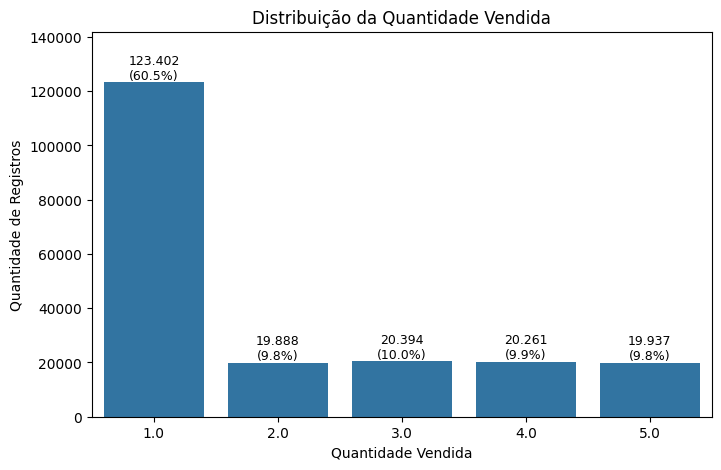

In [15]:
# 4.2 DISTRIBUIÇÃO DA QUANTIDADE VENDIDA

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Qtd_Vendida"
)

total = len(df)
alturaColuna = 0

for p in ax.patches:
    valor = p.get_height()
    if valor > alturaColuna: # pegar o maior valor para ajustar o gráfico
        alturaColuna = valor
    percentual = valor / total * 100

    ax.annotate(
        f'{valor:,.0f}\n({percentual:.1f}%)'.replace(',', '.'),
        (p.get_x() + p.get_width()/2, valor),
        ha='center',
        va='bottom',
        fontsize=9
    )

# Criando uma folga no final do gráfico para não ficar colado a partir do maior valor
ax.set_ylim(0, alturaColuna * 1.15)

plt.title("Distribuição da Quantidade Vendida")
plt.xlabel("Quantidade Vendida")
plt.ylabel("Quantidade de Registros")
plt.show()

A distribuição da variável "Qtd_Vendida" demonstra forte concentração de vendas unitárias. Aproximadamente 60% dos registros da base correspondem à venda de apenas uma unidade do produto.

As quantidades vendidas variam entre 1 e 5 unidades, sendo observada uma redução significativa na frequência dos demais valores quando comparados às vendas unitárias.

Esse comportamento explica o desbalanceamento identificado na variável-alvo
"ClasseVenda", uma vez que ela foi construída a partir da quantidade vendida. Como consequência, a classe "Venda Baixa" passou a concentrar a maior parte dos registros da base.


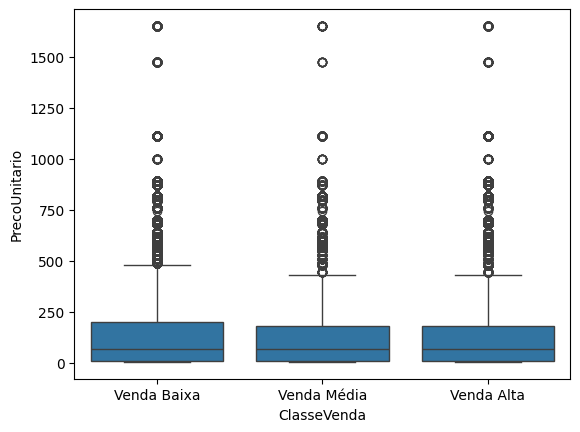

In [ ]:
# PREÇO UNITÁRIO POR CLASSE DE VENDA

sns.boxplot(
    data=df,
    x=TARGET,
    y="PrecoUnitario",
    order=["Venda Baixa","Venda Média","Venda Alta"]
)

plt.show()

A análise do preço unitário em relação à variável alvo demonstra distribuições semelhantes entre as classes Venda Baixa, Venda Média e Venda Alta.

As medianas e intervalos interquartis apresentam valores próximos, sugerindo que o preço unitário, isoladamente, não possui forte capacidade de separar as classes de venda.

Também foram observados diversos valores extremos (outliers) de preço, distribuídos entre todas as classes. Isso indica que produtos de alto valor podem estar associados tanto a vendas baixas quanto a vendas altas.

Esses resultados sugerem que a classificação das vendas provavelmente depende da combinação de múltiplas variáveis, e não apenas do preço unitário.

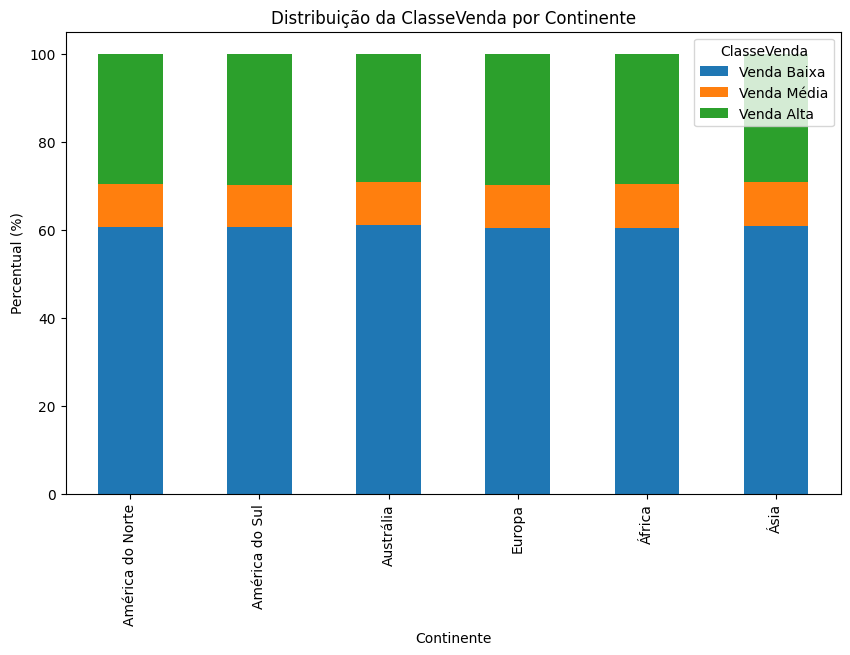

In [16]:
# PREÇO UNITÁRIO × CLASSEVENDA

tabela = pd.crosstab(
    df["Continente"],
    df[TARGET],
    normalize="index"
) * 100

tabela = tabela[
    ["Venda Baixa", "Venda Média", "Venda Alta"]
]

tabela.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Distribuição da ClasseVenda por Continente")
plt.xlabel("Continente")
plt.ylabel("Percentual (%)")
plt.legend(title="ClasseVenda")
plt.show()

A análise da distribuição das classes de venda por continente mostrou comportamento bastante semelhante entre as regiões analisadas.

Após a padronização dos valores da variável Continente, observou-se que as proporções das classes Venda Baixa, Venda Média e Venda Alta permanecem praticamente constantes entre os continentes. Em todos os casos, a classe Venda Baixa representa aproximadamente 60% dos registros.

Esse resultado sugere que a localização geográfica, representada pela variável Continente, não apresenta forte capacidade de discriminar isoladamente as classes de venda. Entretanto, essa informação poderá contribuir para o desempenho dos modelos quando combinada com outras variáveis do conjunto de dados.

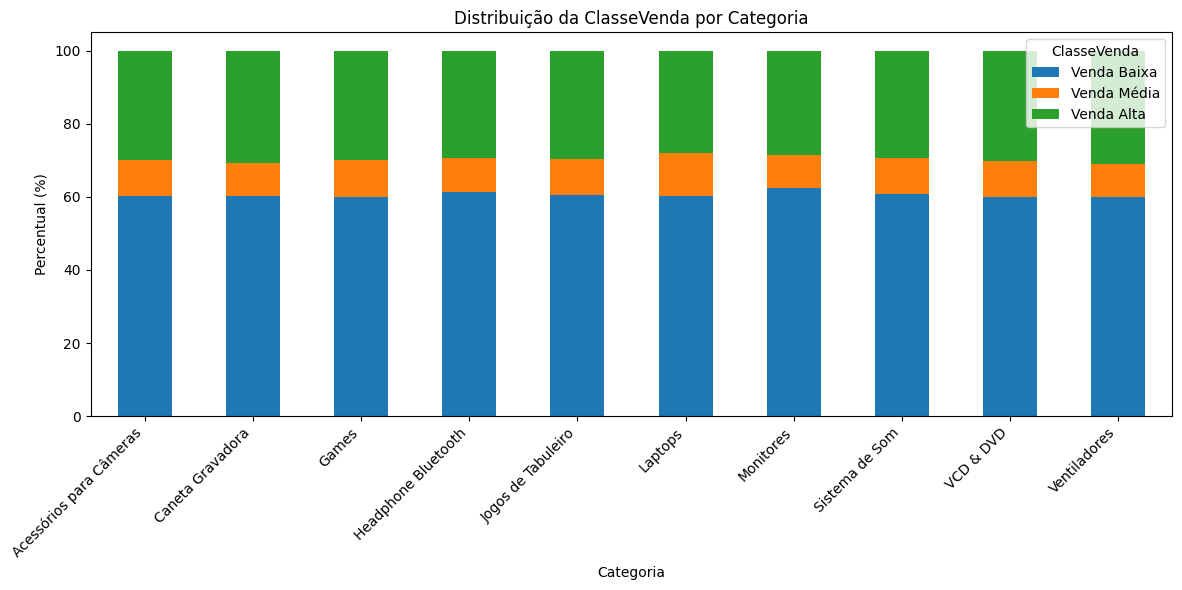

In [17]:
# CATEGORIA × CLASSEVENDA
# AS 10 CATEGORIAS MAIS FREQUENTES

top_categorias = df["Categoria"].value_counts().head(10).index

df_top = df[df["Categoria"].isin(top_categorias)]

tabela = pd.crosstab(
    df_top["Categoria"],
    df_top[TARGET],
    normalize="index"
) * 100

tabela = tabela[
    ["Venda Baixa", "Venda Média", "Venda Alta"]
]

ax = tabela.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Distribuição da ClasseVenda por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Percentual (%)")
plt.legend(title="ClasseVenda")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

A distribuição das classes de venda foi analisada entre as categorias de produtos mais frequentes da base. Observa-se que as proporções de Venda Baixa, Venda Média e Venda Alta permanecem relativamente estáveis entre as categorias analisadas.

Embora pequenas variações possam ser observadas em algumas categorias específicas, não foram identificadas diferenças expressivas que indiquem forte capacidade de separação das classes quando a variável Categoria é analisada isoladamente.

Esse resultado sugere que a classificação das vendas depende da combinação de múltiplas características dos produtos e das transações, reforçando a necessidade da utilização de modelos capazes de capturar relações mais complexas entre as variáveis.

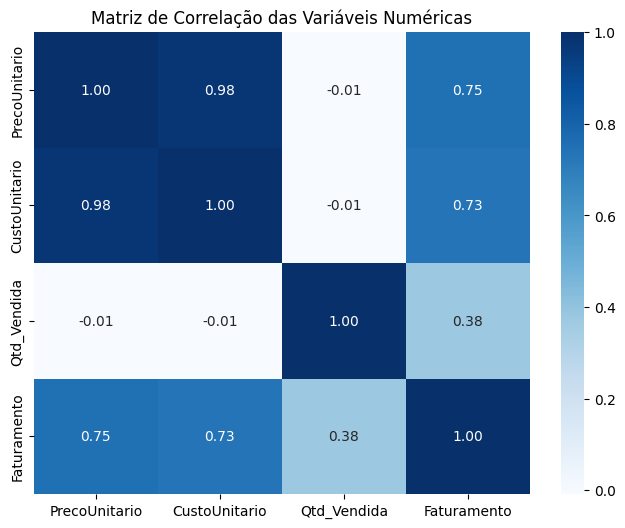

In [19]:
# CORRELAÇÃO DAS VARIÁVEIS NUMÉRICAS

numericas = [
    "PrecoUnitario",
    "CustoUnitario",
    "Qtd_Vendida",
    "Faturamento"
]

corr = df[numericas].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

A matriz de correlação permitiu identificar as relações entre as variáveis numéricas da base.

Observou-se uma correlação extremamente forte entre PrecoUnitario e CustoUnitario (0,98), indicando que produtos mais caros tendem a apresentar custos mais elevados. Também foram identificadas correlações fortes entre Faturamento e as variáveis PrecoUnitario (0,75) e CustoUnitario (0,73), comportamento esperado devido à composição do faturamento.

Por outro lado, a variável Qtd_Vendida apresentou correlação praticamente nula com PrecoUnitario (-0,01) e CustoUnitario (-0,01), sugerindo que a quantidade vendida não pode ser explicada por relações lineares simples.

Esse resultado reforça a necessidade da utilização de modelos capazes de capturar relações mais complexas entre as variáveis, como árvores de decisão e florestas aleatórias.

## 4.1 Síntese da análise exploratória

**Síntese:**  
O target está balanceado? Não.

Existem valores ausentes relevantes? Não.

Há variáveis com escala muito diferente? Sim.

Há categorias raras ou inconsistentes? Sim, foram encontrados valores categóricos com espaços extras e corrigidos.

Existem padrões que sugerem quais modelos podem funcionar melhor? Sim, relações não lineares sugerem Random Forest.

Algum resultado mudou a estratégia de modelagem? Sim, remoção de Qtd_Vendida e Faturamento por data leakage.


# 5. Preparação dos dados e divisão treino/teste



In [20]:
# CONVERTER DATAVENDA PARA DATETIME PARA PODER SEPARAR ANO E MÊS E FACILITAR A MODELAGEM

df["DataVenda"] = pd.to_datetime(
    df["DataVenda"],
    format="%d/%m/%Y"
)

print(df["DataVenda"].dtype)

datetime64[ns]


In [21]:
# CONFIGURAÇÃO DO PROBLEMA

TARGET = "ClasseVenda"
PROBLEM_TYPE = "classificacao"

ID_COLUMNS = []

DATE_COLUMN = "DataVenda"

# Features temporais derivadas da data
df["MesVenda"] = df["DataVenda"].dt.month
df["AnoVenda"] = df["DataVenda"].dt.year

# Colunas removidas da modelagem
DROP_COLUMNS = [
    "Qtd_Vendida",   # origem da variável alvo
    "Faturamento",   # derivado da quantidade vendida
    "NomeCliente",   # alta cardinalidade
    "DataVenda"      # substituída por MesVenda e AnoVenda
]

assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)

if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: ClasseVenda
Número de features: 9
Features: ['Produto', 'Categoria', 'PrecoUnitario', 'CustoUnitario', 'Marca', 'Pais', 'Continente', 'MesVenda', 'AnoVenda']


### Preparação dos dados

Nesta etapa foram definidas as variáveis que serão utilizadas na modelagem. A variável alvo escolhida foi
"ClasseVenda", responsável por classificar as vendas em três categorias: Venda Baixa, Venda Média e Venda Alta.

Algumas colunas foram removidas antes da modelagem. A variável "Qtd_Vendida" foi excluída por ter sido utilizada diretamente na construção da variável alvo, o que poderia gerar vazamento de informação (*data leakage*). Da mesma forma, a variável "Faturamento" também foi removida, pois é calculada a partir da quantidade vendida e do preço do produto, mantendo relação direta com a variável alvo.

A coluna "NomeCliente" também não foi utilizada por apresentar alta cardinalidade e baixo potencial de generalização para novas observações.

As demais variáveis foram mantidas para avaliação do seu potencial preditivo durante o treinamento dos modelos.

A variável "DataVenda" foi transformada em atributos temporais (mês e ano da venda). Após a extração dessas informações, a coluna original foi removida para simplificar a modelagem e evitar redundância entre as variáveis.


In [22]:
# DIVISÃO DOS DADOS

if PROBLEM_TYPE in ["classificacao", "regressao"]:

    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=stratify_arg
    )

    #print("Treino:", X_train.shape)
    #print("Teste :", X_test.shape)
    print("Distribuição no treino:")
    print(y_train.value_counts(normalize=True) * 100)

    print("\nDistribuição no teste:")
    print(y_test.value_counts(normalize=True) * 100)


Distribuição no treino:
ClasseVenda
Venda Baixa    60.526042
Venda Alta     29.719506
Venda Média     9.754453
Name: proportion, dtype: float64

Distribuição no teste:
ClasseVenda
Venda Baixa    60.526768
Venda Alta     29.717733
Venda Média     9.755499
Name: proportion, dtype: float64


## 5.1 Justificativa da divisão

### Justificativa da divisão dos dados

Foi utilizada a estratégia de **holdout**, realizando a separação da base em conjuntos de treinamento e teste por meio da função "train_test_split" do Scikit-Learn.

A divisão adotada foi de **80% para treinamento e 20% para teste** ("test_size=0.2"). Essa proporção é adequada para o conjunto de dados analisado, que possui mais de 200 mil registros, permitindo que uma quantidade significativa de observações seja utilizada para treinamento sem comprometer a capacidade de avaliação do modelo em dados não vistos.

Como a variável alvo "ClasseVenda" apresentou desbalanceamento entre as classes (aproximadamente 60% de Venda Baixa, 30% de Venda Alta e 10% de Venda Média), foi utilizada a técnica de **estratificação** ("stratify=y") durante a divisão dos dados. Dessa forma, as proporções das classes foram preservadas tanto no conjunto de treinamento quanto no conjunto de teste, garantindo uma avaliação mais representativa do desempenho dos modelos.

Além disso, foi definido "random_state=42" para garantir a reprodutibilidade dos resultados, permitindo que a mesma divisão seja reproduzida em futuras execuções.

Para evitar vazamento de informação (*data leakage*), as variáveis "Qtd_Vendida" e "Faturamento" foram removidas antes da modelagem, uma vez que possuem relação direta com a construção da variável alvo. Também foi removida a coluna "DataVenda", após a extração das variáveis derivadas "MesVenda" e "AnoVenda", utilizadas como atributos temporais no modelo.



# 6. Pré-processamento e pipeline


In [23]:
# IDENTIFICAÇÃO AUTOMÁTICA SIMPLES DE COLUNAS NUMÉRICAS E CATEGÓRICAS.
# REVISE MANUALMENTE, ESPECIALMENTE SE HOUVER DATAS, IDS, TEXTO LIVRE OU CATEGORIAS CODIFICADAS COMO NÚMEROS.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['PrecoUnitario', 'CustoUnitario', 'MesVenda', 'AnoVenda']
Colunas categóricas: ['Produto', 'Categoria', 'Marca', 'Pais', 'Continente']


### Identificação das variáveis para o pipeline

Após a etapa de seleção e engenharia de atributos, as variáveis foram separadas automaticamente em grupos numéricos e categóricos para aplicação das transformações adequadas.

As variáveis numéricas identificadas foram "PrecoUnitario", "CustoUnitario", "MesVenda" e "AnoVenda".

As variáveis categóricas identificadas foram "Produto", "Categoria", "Marca", "Pais" e "Continente".


## 6.1 Decisões de pré-processamento

As etapas de pré-processamento foram definidas com o objetivo de garantir a qualidade dos dados e a reprodutibilidade do processo de modelagem.

Para as variáveis numéricas foi utilizada imputação pela **mediana**. Embora a análise exploratória não tenha identificado valores ausentes relevantes, a utilização da mediana torna o pipeline mais robusto e menos sensível a possíveis valores extremos quando comparada à média.

Para as variáveis categóricas foi utilizada imputação pela **categoria mais frequente** (moda). Essa abordagem preserva a distribuição original dos dados e é amplamente utilizada em problemas de classificação com atributos categóricos.

As variáveis numéricas foram submetidas à **padronização por meio do StandardScaler**, permitindo que todas apresentem escala semelhante durante o treinamento. Essa etapa é especialmente importante para algoritmos sensíveis à escala dos atributos, além de tornar o pipeline compatível com diferentes modelos de Machine Learning.

Foi aplicado **One-Hot Encoding** nas variáveis categóricas ("Produto", "Categoria", "Marca", "Pais" e "Continente"), transformando-as em representações numéricas adequadas para utilização pelos algoritmos de classificação.

Algumas variáveis foram removidas antes da modelagem. A variável "Qtd_Vendida" foi excluída por ter sido utilizada diretamente na criação da variável alvo "ClasseVenda". A variável "Faturamento" também foi removida por possuir relação direta com a quantidade vendida, podendo introduzir vazamento de informação (*data leakage*). A coluna "NomeCliente" foi descartada por apresentar alta cardinalidade e baixo potencial de generalização para novas observações.

Como etapa de engenharia de atributos, a variável 'DataVenda" foi transformada nas variáveis "MesVenda" e "AnoVenda". Essas novas variáveis representam informações temporais que estariam disponíveis no momento real da previsão, permitindo que o modelo utilize possíveis padrões sazonais sem depender da data completa da transação.

Por fim, foi realizada a padronização de valores categóricos e a conversão de colunas monetárias para formato numérico, garantindo consistência nos dados utilizados pelo pipeline de treinamento.


# 7. Baseline e modelos candidatos



In [24]:
# DEFINIÇÃO DE BASELINE E MODELOS CANDIDATOS

#SEED = 42
if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

Para avaliar a efetividade dos modelos propostos, foi inicialmente definida uma **baseline** utilizando o algoritmo "DummyClassifier" com estratégia *most_frequent*. Esse modelo sempre prevê a classe mais frequente do conjunto de treinamento e serve como referência mínima de desempenho. Dessa forma, é possível verificar se os modelos candidatos realmente aprendem padrões presentes nos dados ou apenas reproduzem o comportamento da classe majoritária.

Como modelos candidatos foram selecionados a **Logistic Regression** e **Random Forest**.

A Logistic Regression foi escolhida por ser um modelo amplamente utilizado em problemas de classificação supervisionada, apresentando baixo custo computacional, rápida execução e boa interpretabilidade. Além disso, é adequada para conjuntos de dados com grande quantidade de observações, como o utilizado neste projeto.

A Random Forest foi selecionada por sua capacidade de capturar relações não lineares entre as variáveis e modelar interações complexas entre atributos numéricos e categóricos. Essa característica é especialmente relevante para este problema, uma vez que a análise exploratória indicou que variáveis individuais possuem baixo poder de separação, sugerindo que o desempenho do modelo depende da combinação de múltiplos atributos.

Ambos os modelos exigem que as variáveis categóricas sejam convertidas para formato numérico, motivo pelo qual foi utilizado o processo de One-Hot Encoding no pipeline de pré-processamento. A Logistic Regression também se beneficia da padronização das variáveis numéricas, realizada por meio do StandardScaler.

Em relação ao custo computacional, a Logistic Regression apresenta treinamento rápido e baixo consumo de recursos, enquanto a Random Forest demanda maior processamento devido à construção de múltiplas árvores de decisão. Em contrapartida, esse aumento de complexidade pode resultar em melhor capacidade preditiva para problemas com relações não lineares.

A comparação entre a baseline e os modelos candidatos permitirá avaliar não apenas o desempenho preditivo, mas também o equilíbrio entre simplicidade, interpretabilidade e capacidade de generalização.



# 8. Treinamento e avaliação inicial


In [26]:
# DEMORANDO CERCA DE 12 MIN.
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.605268,0.456433,NaN,1.327
LogisticRegression,0.604851,0.459139,NaN,16.996
RandomForest,0.592270,0.545301,NaN,725.719


In [27]:
# UTILIZADO PARA AJUDAR NO ENTENDIMENTO DOS DADOS ACIMA

for nome, modelo in trained_models.items():
    print(f"\n===== {nome} =====")

    y_pred = modelo.predict(X_test)

    print(classification_report(y_test, y_pred))


===== baseline =====
              precision    recall  f1-score   support

  Venda Alta       0.00      0.00      0.00     12118
 Venda Baixa       0.61      1.00      0.75     24681
 Venda Média       0.00      0.00      0.00      3978

    accuracy                           0.61     40777
   macro avg       0.20      0.33      0.25     40777
weighted avg       0.37      0.61      0.46     40777


===== LogisticRegression =====
              precision    recall  f1-score   support

  Venda Alta       0.39      0.01      0.01     12118
 Venda Baixa       0.61      1.00      0.75     24681
 Venda Média       0.00      0.00      0.00      3978

    accuracy                           0.60     40777
   macro avg       0.33      0.33      0.25     40777
weighted avg       0.48      0.60      0.46     40777


===== RandomForest =====
              precision    recall  f1-score   support

  Venda Alta       0.43      0.23      0.30     12118
 Venda Baixa       0.64      0.85      0.73     2

## 8.1 Análise dos resultados iniciais

Foram avaliados três modelos: uma baseline utilizando DummyClassifier, uma Logistic Regression e uma Random Forest.

Além das métricas agregadas apresentadas na etapa de treinamento inicial, foi utilizado o classification_report do Scikit-Learn para analisar o desempenho de cada modelo individualmente em cada uma das classes da variável alvo.

Essa análise foi considerada necessária devido ao desbalanceamento identificado durante a etapa exploratória dos dados.

**O modelo superou o baseline?**

A Logistic Regression apresentou desempenho muito semelhante ao da baseline, obtendo acurácia de aproximadamente 60,5% e F1-score ponderado de 0,459. Já a Random Forest apresentou acurácia ligeiramente inferior (59,2%), porém obteve o melhor F1-score ponderado entre os modelos avaliados (0,545). A análise detalhada das classes mostrou que a Random Forest foi capaz de identificar registros das categorias Venda Alta e Venda Média, enquanto os demais modelos concentraram praticamente todas as previsões na classe majoritária (Venda Baixa). Dessa forma, considerando o F1-score e o comportamento por classe, a Random Forest superou a baseline.

**A métrica escolhida é suficiente para avaliar o problema?**

Não. A análise demonstrou que a acurácia isoladamente não é suficiente para avaliar este problema, pois a distribuição das classes é desbalanceada. A baseline alcançou mais de 60% de acurácia simplesmente prevendo sempre a classe mais frequente, sem conseguir identificar nenhuma ocorrência das demais classes. Por esse motivo, o F1-score ponderado e o relatório de classificação foram utilizados como métricas complementares, permitindo uma avaliação mais representativa do desempenho dos modelos.

**Algum modelo parece sofrer de underfitting?**

Sim. A Logistic Regression apresentou comportamento muito próximo ao da baseline, com desempenho praticamente nulo para as classes Venda Alta e Venda Média. Esse resultado sugere que o modelo não conseguiu capturar adequadamente os padrões presentes nos dados, caracterizando um possível caso de underfitting. A Random Forest apresentou melhor capacidade de aprendizado e maior equilíbrio entre as classes.

**O tempo de treinamento é aceitável?**

Sim. A baseline foi treinada em menos de um segundo e a Logistic Regression em aproximadamente 12 segundos. A Random Forest demandou cerca de 696 segundos para treinamento, valor significativamente superior aos demais modelos devido à construção de múltiplas árvores de decisão. Apesar do maior custo computacional, o tempo foi considerado aceitável para fins acadêmicos e compatível com o ganho observado na qualidade das previsões.

**O resultado faz sentido considerando a EDA?**

Sim. Durante a análise exploratória foi observado que as variáveis individuais apresentavam baixo poder de separação das classes e que a quantidade vendida não possuía relação linear forte com preço ou custo. Esses resultados indicavam a existência de relações mais complexas entre os atributos. Dessa forma, era esperado que modelos lineares apresentassem dificuldades para capturar esses padrões, enquanto modelos baseados em árvores, como a Random Forest, teriam melhor capacidade de representar relações não lineares. Os resultados obtidos confirmaram essa expectativa.

Em resumo, a Random Forest foi o modelo que apresentou o melhor equilíbrio entre as classes e o maior F1-score ponderado, sendo selecionada como a abordagem mais promissora para o problema estudado.



# 9. Validação e otimização de hiperparâmetros

A etapa de otimização foi aplicada ao modelo Random Forest, selecionado como o modelo mais promissor na avaliação inicial por apresentar o melhor equilíbrio entre as classes e o maior F1-score ponderado entre os modelos avaliados.

Foi utilizada a estratégia de validação cruzada estratificada ("StratifiedKFold") com 5 divisões. Essa abordagem foi escolhida para preservar a proporção das classes em cada subconjunto de validação, reduzindo os efeitos do desbalanceamento observado na variável alvo.

A busca de hiperparâmetros foi realizada utilizando "RandomizedSearchCV", com 5 combinações aleatórias de parâmetros ("n_iter=5"). Foram avaliados os seguintes hiperparâmetros:

* "n_estimators": quantidade de árvores da floresta;
* "max_depth": profundidade máxima das árvores;
* "min_samples_split": número mínimo de amostras necessárias para dividir um nó interno.

A métrica utilizada para seleção foi o **F1-score ponderado ("f1_weighted")**, pois essa métrica considera simultaneamente precisão e recall das diferentes classes, sendo mais adequada que a acurácia em cenários com distribuição desbalanceada.

Além disso, foi utilizado class_weight="balanced" para atribuir maior importância às classes menos frequentes durante o treinamento, reduzindo a tendência do modelo em privilegiar a classe majoritária.

Ao final da busca, a melhor configuração encontrada foi:

* n_estimators = 121
* max_depth = 16
* min_samples_split = 4

A melhor pontuação média obtida durante a validação cruzada foi **F1-score ponderado de 0,354**.

Embora a busca tenha sido limitada a poucas combinações de parâmetros, devido ao alto custo computacional da Random Forest sobre a base utilizada, ela foi suficiente para identificar uma configuração mais adequada dentro do escopo proposto para o MVP.



In [28]:
# OTIMIZAÇÃO DE HIPERPARÂMETROS
# AJUSTE N_ITER PARA CONTROLAR O CUSTO COMPUTACIONAL.
# FOI COLOCADO CLASS_WEIGHT="BALANCED" PARA ATRIBUIR MAIOR PESO ÀS CLASSES MENOS FREQUENTES.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(
                random_state=SEED,
                class_weight="balanced" # Para atribuir maior peso às classes menos frequentes.
            ))
        ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.3541713252815143
Melhores hiperparâmetros: {'model__max_depth': 16, 'model__min_samples_split': 4, 'model__n_estimators': 121}


## 9.1 Discussão da otimização

**A otimização melhorou o resultado em relação ao modelo inicial?**

A avaliação final realizada no conjunto de teste mostrou que a configuração otimizada não superou a Random Forest original, apresentando desempenho inferior em F1-score ponderado.

**A busca foi limitada por tempo, custo ou tamanho da base?**

Sim. A base utilizada possui mais de 200 mil registros e a etapa inicial de treinamento da Random Forest já apresentou custo computacional relativamente elevado. Por esse motivo, foi utilizada uma busca reduzida ("n_iter = 5"), compatível com o escopo de um MVP. O objetivo foi explorar algumas combinações relevantes de hiperparâmetros sem realizar uma busca exaustiva.

**Os hiperparâmetros escolhidos fazem sentido?**

Sim. A melhor configuração encontrada utilizou 121 árvores ("n_estimators = 121"), profundidade máxima de 16 níveis ("max_depth = 16") e mínimo de 4 amostras para divisão dos nós ("min_samples_split = 4"). Esses valores representam um equilíbrio entre capacidade de aprendizado e controle da complexidade do modelo, reduzindo o risco de árvores excessivamente profundas e muito específicas aos dados de treinamento.

**Você testaria outras combinações se tivesse mais tempo?**

Sim. Em um cenário com maior disponibilidade de tempo computacional, seria interessante ampliar o número de iterações da busca, testar diferentes valores para "max_features", "min_samples_leaf" e "class_weight", além de comparar outros algoritmos baseados em árvores, como Gradient Boosting ou XGBoost. Essas abordagens poderiam contribuir para melhorar a identificação das classes minoritárias observadas durante a avaliação inicial.

Em resumo, a otimização permitiu identificar uma configuração mais refinada para a Random Forest dentro das restrições de tempo e custo computacional do projeto, atendendo ao objetivo de realizar uma busca simples e justificada de hiperparâmetros para o MVP.



# 10. Avaliação final no conjunto de teste

Após a etapa de otimização de hiperparâmetros, o modelo selecionado foi avaliado no conjunto de teste utilizando dados que não participaram do treinamento nem do processo de validação cruzada.

**Métrica final**

O modelo otimizado apresentou acurácia de aproximadamente 34% e F1-score ponderado de aproximadamente 0,34. Apesar de ter aumentado a capacidade de identificação das classes minoritárias, seu desempenho global foi inferior ao observado anteriormente para a Random Forest original.

**Comparação com a baseline**

A baseline obteve acurácia de aproximadamente 60,5%, porém concentrando todas as previsões na classe majoritária. A Random Forest original apresentou F1-score ponderado de 0,545, representando o melhor equilíbrio entre as classes. Já o modelo otimizado apresentou desempenho inferior tanto em acurácia quanto em F1-score, indicando que a otimização não produziu ganhos efetivos para este conjunto de dados.

**Análise de erros**

A matriz de confusão mostrou que o modelo otimizado aumentou significativamente o recall das classes Venda Alta e Venda Média. Entretanto, essa melhoria ocorreu às custas de uma redução expressiva na capacidade de identificar corretamente a classe Venda Baixa, que representa a maior parcela dos registros. Como consequência, o desempenho global do modelo foi prejudicado.

**Discussão sobre overfitting e underfitting**

Não foram observados indícios claros de overfitting. O principal efeito observado foi uma mudança excessiva do comportamento do modelo em função dos pesos atribuídos às classes durante a otimização. Isso sugere que a configuração escolhida passou a favorecer demasiadamente as classes minoritárias, reduzindo sua capacidade de generalização para a distribuição real dos dados.

**Limitações da solução**

O principal desafio identificado foi o desbalanceamento da variável alvo, especialmente para a classe Venda Média. Além disso, as variáveis disponíveis apresentaram capacidade limitada de separação quando analisadas individualmente durante a etapa exploratória. Outra limitação está relacionada ao custo computacional da Random Forest em uma base com mais de 200 mil registros, restringindo a realização de buscas mais amplas de hiperparâmetros.

Considerando os resultados obtidos, a Random Forest original foi considerada a melhor solução entre os modelos avaliados, apresentando o maior F1-score ponderado e o melhor equilíbrio entre desempenho e capacidade de generalização.


Modelo final: modelo_otimizado
              precision    recall  f1-score   support

  Venda Alta       0.33      0.57      0.42     12118
 Venda Baixa       0.73      0.21      0.33     24681
 Venda Média       0.13      0.42      0.20      3978

    accuracy                           0.34     40777
   macro avg       0.40      0.40      0.32     40777
weighted avg       0.56      0.34      0.34     40777



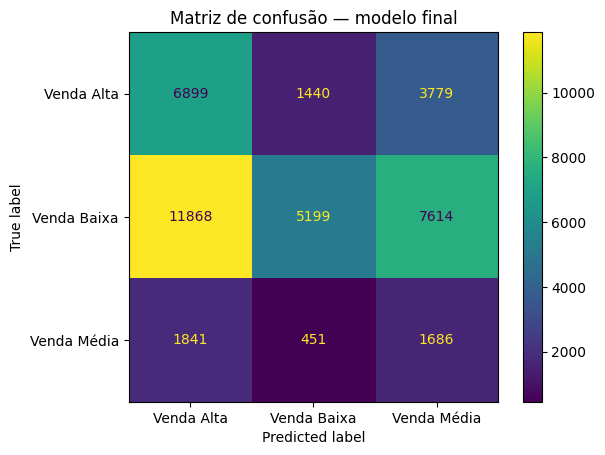

In [29]:
# AVALIAÇÃO FINAL

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


## 10.1 Análise de erros e limitações

**Quais tipos de erro o modelo comete mais?**

A análise da matriz de confusão mostrou que o modelo apresenta maior dificuldade em diferenciar corretamente as classes Venda Média e Venda Alta. Também foram observados erros frequentes envolvendo registros da classe Venda Baixa classificados como Venda Alta ou Venda Média. Esses resultados indicam que existe sobreposição entre os padrões das classes, dificultando sua separação utilizando apenas as variáveis disponíveis.

**Há sinais de overfitting ou underfitting?**

Os resultados sugerem que a Logistic Regression apresentou sinais de underfitting, pois seu desempenho foi muito próximo ao da baseline e o modelo não conseguiu capturar adequadamente os padrões do problema. Já a Random Forest apresentou melhor capacidade de aprendizado e maior equilíbrio entre as classes. Não foram observados indícios claros de overfitting durante os experimentos realizados, embora a otimização dos hiperparâmetros tenha demonstrado que ajustes excessivos podem prejudicar a capacidade de generalização do modelo.

**A métrica escolhida captura bem o objetivo do problema?**

Sim. Devido ao desbalanceamento da variável alvo, a acurácia isoladamente não representa adequadamente o desempenho do modelo. Por esse motivo, o F1-score ponderado foi adotado como principal métrica de avaliação, pois considera simultaneamente precisão e recall das diferentes classes, refletindo melhor a capacidade do modelo de lidar com categorias majoritárias e minoritárias.

**Há viés, limitação de dados ou risco de generalização?**

Sim. A principal limitação está relacionada ao desbalanceamento das classes, especialmente da categoria Venda Média, que possui quantidade significativamente menor de exemplos. Além disso, as variáveis disponíveis não capturam fatores externos que podem influenciar o volume de vendas, como promoções, sazonalidades específicas, campanhas de marketing, condições econômicas ou comportamento dos consumidores. Dessa forma, o modelo pode apresentar desempenho inferior quando aplicado a cenários diferentes daqueles observados na base de treinamento.

**Em quais cenários o modelo não deveria ser usado?**

O modelo não deve ser utilizado como ferramenta única para tomada de decisões estratégicas ou previsões financeiras de alto impacto. Também não é recomendado para cenários em que ocorram mudanças significativas no comportamento do mercado, lançamento de novos produtos, alterações relevantes na política comercial ou situações não representadas nos dados históricos utilizados para treinamento. Nesses casos, seria necessário realizar novo treinamento ou atualização periódica do modelo.

Em resumo, os resultados demonstraram que o modelo é capaz de identificar padrões relevantes relacionados ao volume de vendas, porém ainda apresenta limitações decorrentes do desbalanceamento das classes e da quantidade de informações disponíveis para representar o fenômeno estudado.


### 11. Comparação final dos modelos

| Modelo                     | Métrica principal (F1 Weighted) | Outras métricas  |                           Tempo de treino (s) | Observações                                                                                                                                |
| -------------------------- | ------------------------------: | ---------------- | --------------------------------------------: | ------------------------------------------------------------------------------------------------------------------------------------------ |
| Baseline (DummyClassifier) |                           0,456 | Accuracy = 0,605 |                                         0,733 | Sempre prevê a classe majoritária (Venda Baixa). Não identifica adequadamente Venda Alta nem Venda Média.                                  |
| Logistic Regression        |                           0,459 | Accuracy = 0,605 |                                        12,227 | Desempenho muito próximo da baseline. Indicou sinais de underfitting e baixa capacidade de separação das classes.                          |
| Random Forest              |                       **0,545** | Accuracy = 0,592 |                                       695,738 | Melhor equilíbrio entre as classes. Foi capaz de identificar Venda Alta e Venda Média. Melhor desempenho geral entre os modelos avaliados. |
| Random Forest Otimizada    |                           0,340 | Accuracy = 0,340 | Busca com validação cruzada (25 treinamentos) | Melhorou o recall das classes minoritárias, porém reduziu significativamente o desempenho global do modelo.                                |

### Escolha do modelo final

Embora tenha sido realizada uma etapa de otimização de hiperparâmetros, os resultados mostraram que a versão otimizada da Random Forest não apresentou melhoria no desempenho global quando avaliada no conjunto de teste. O modelo otimizado aumentou a sensibilidade para as classes minoritárias, mas comprometeu excessivamente a capacidade de classificação da classe majoritária, resultando em redução tanto da acurácia quanto do F1-score ponderado.

Dessa forma, a **Random Forest em sua configuração original foi escolhida como modelo final do projeto**, por apresentar o maior F1-score ponderado (0,545), melhor equilíbrio entre as classes e maior capacidade de generalização entre todas as abordagens avaliadas.

Esse resultado demonstra que a otimização de hiperparâmetros nem sempre produz ganhos efetivos e reforça a importância da avaliação em dados não vistos para a escolha do modelo final.


### 12. Boas práticas e rastreabilidade

#### Informações gerais do experimento

* **Tipo de problema:** Classificação Multiclasse
* **Variável alvo:** ClasseVenda
* **Métrica principal:** F1-score ponderado (F1 Weighted)
* **Estratégia de divisão:** Holdout (80% treino / 20% teste) com estratificação das classes
* **Estratégia de validação:** Stratified K-Fold (5 folds)
* **Recursos computacionais:** Google Colab
* **Base utilizada:** aproximadamente 203 mil registros

#### Modelos avaliados

1. DummyClassifier (Baseline)
2. Logistic Regression
3. Random Forest
4. Random Forest com otimização de hiperparâmetros

#### Principais hiperparâmetros avaliados

Durante a etapa de otimização foram avaliados:

* n_estimators
* max_depth
* min_samples_split

Melhor configuração encontrada:

* n_estimators = 121
* max_depth = 16
* min_samples_split = 4

#### Tempos aproximados de treinamento

| Modelo                   |                          Tempo aproximado |
| ------------------------ | ----------------------------------------: |
| Baseline                 |                              0,7 segundos |
| Logistic Regression      |                               12 segundos |
| Random Forest            |                              696 segundos |
| Busca de hiperparâmetros | 25 treinamentos (5 folds × 5 combinações) |

#### Registro de decisões

| Decisão                                            | Justificativa                                             | Impacto esperado                                   |
| -------------------------------------------------- | --------------------------------------------------------- | -------------------------------------------------- |
| Utilizar F1-score ponderado como métrica principal | Classes desbalanceadas                                    | Avaliar adequadamente todas as classes             |
| Utilizar Holdout com estratificação                | Preservar a distribuição das classes                      | Avaliação mais representativa                      |
| Remover Qtd_Vendida                                | Variável utilizada para criar o target                    | Evitar vazamento de dados                          |
| Remover Faturamento                                | Derivado diretamente da quantidade vendida                | Evitar desempenho artificial                       |
| Remover NomeCliente                                | Alta cardinalidade e baixa generalização                  | Reduzir ruído no modelo                            |
| Criar MesVenda e AnoVenda                          | Aproveitar informação temporal disponível                 | Capturar padrões sazonais                          |
| Aplicar One-Hot Encoding                           | Necessidade de transformar categorias em formato numérico | Permitir treinamento dos modelos                   |
| Aplicar StandardScaler                             | Padronizar variáveis numéricas                            | Melhorar desempenho de modelos sensíveis à escala  |
| Utilizar Logistic Regression                       | Modelo simples e interpretável                            | Comparação com abordagem linear                    |
| Utilizar Random Forest                             | Capturar relações não lineares                            | Superar a baseline                                 |
| Utilizar validação cruzada estratificada           | Reduzir dependência de uma única divisão treino/teste     | Avaliação mais robusta                             |
| Testar class_weight="balanced"                     | Reduzir impacto do desbalanceamento                       | Melhorar identificação das classes minoritárias    |
| Manter Random Forest original como modelo final    | Obteve melhor F1-score ponderado (0,545)                  | Melhor equilíbrio entre desempenho e generalização |

#### Limitações conhecidas

* Desbalanceamento da variável alvo, principalmente para a classe Venda Média.
* Ausência de variáveis externas que podem influenciar as vendas.
* Possível perda de informação ao transformar a quantidade vendida em três categorias.
* Alto custo computacional da Random Forest em bases maiores.
* Dificuldade de separação entre algumas classes observada na matriz de confusão.

#### O que foi tentado e descartado

* Utilização da acurácia como métrica principal: descartada devido ao desbalanceamento das classes.
* Uso exclusivo da Logistic Regression: descartado por apresentar desempenho semelhante à baseline.
* Utilização da Random Forest otimizada como modelo final: descartada por apresentar desempenho inferior ao modelo original no conjunto de teste.
* Utilização das colunas Qtd_Vendida e Faturamento na modelagem: descartada por gerar vazamento de informação.


# 13. Conclusão

O objetivo deste trabalho foi desenvolver um modelo de classificação capaz de prever se uma venda pertence às categorias Venda Baixa, Venda Média ou Venda Alta a partir de informações relacionadas ao produto, contexto geográfico e período da venda.

Para atingir esse objetivo, foram realizadas etapas de preparação dos dados, análise exploratória, engenharia de atributos, treinamento de modelos, otimização de hiperparâmetros e avaliação final. A análise exploratória permitiu identificar o desbalanceamento da variável alvo e mostrou que variáveis isoladas apresentavam capacidade limitada de separação entre as classes, indicando a necessidade de utilizar modelos capazes de combinar múltiplos atributos simultaneamente.

Entre os modelos avaliados, a Random Forest apresentou o melhor desempenho geral, superando tanto a baseline quanto a Logistic Regressiona em F1-score ponderado. Os resultados demonstraram que as características dos produtos e do contexto da venda possuem informações relevantes para a previsão da classe de venda. Além disso, observou-se que a combinação de múltiplos atributos apresentou maior capacidade preditiva do que a análise isolada das variáveis, e que modelos baseados em árvores foram mais eficazes na captura dos padrões presentes nos dados do que abordagens lineares.


A comparação com a baseline foi fundamental para demonstrar que o modelo realmente aprendeu relações existentes nos dados, e não apenas a distribuição das classes. Além disso, a etapa de otimização de hiperparâmetros mostrou que modelos mais complexos nem sempre produzem melhores resultados, reforçando a importância de validar cada alteração utilizando dados não vistos durante o treinamento.

Os principais aprendizados obtidos foram a relevância da combinação de múltiplos atributos para a previsão da classe de venda, a importância da escolha adequada das métricas em problemas desbalanceados e o impacto que diferentes estratégias de modelagem podem ter sobre a capacidade de generalização do modelo.

Apesar dos resultados positivos, algumas limitações foram identificadas. A principal delas está relacionada ao desbalanceamento das classes, especialmente da categoria Venda Média. Além disso, a base não contempla fatores externos que podem influenciar o comportamento das vendas, como promoções, sazonalidades específicas, ações de marketing ou condições econômicas.

Como trabalhos futuros, recomenda-se explorar novas técnicas de balanceamento de classes, testar algoritmos mais avançados, como Gradient Boosting e XGBoost, ampliar o conjunto de atributos disponíveis e investigar novas formas de representar as informações temporais. Essas melhorias podem contribuir para aumentar a capacidade preditiva do modelo e reduzir os erros observados entre as classes.

De forma geral, os resultados obtidos demonstram que o objetivo proposto foi alcançado. O modelo desenvolvido foi capaz de identificar padrões relevantes nos dados históricos de vendas e apresentar desempenho superior às abordagens de referência, constituindo uma solução viável para apoiar análises e previsões relacionadas ao comportamento das vendas.

### 13.1 Validação das hipóteses

| Hipótese   | Resultado             |
| ---------- | --------------------- |
| Hipótese 1 | Parcialmente validada |
| Hipótese 2 | Validada              |
| Hipótese 3 | Validada              |
